In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(cancer.target, name="Target")

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

X.head()

Dataset shape: (569, 30)

Target distribution:
Target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [5]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [7]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted probabilities:")
print(y_proba[:10])

First 10 predicted probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [8]:
threshold = 0.5

y_pred_05 = (y_proba >= threshold).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05)

print("Confusion Matrix at Threshold 0.5")
print(cm_05)

print("\nPrecision:", round(precision_score(y_test, y_pred_05), 4))
print("Recall:", round(recall_score(y_test, y_pred_05), 4))
print("F1-score:", round(f1_score(y_test, y_pred_05), 4))

Confusion Matrix at Threshold 0.5
[[41  1]
 [ 1 71]]

Precision: 0.9861
Recall: 0.9861
F1-score: 0.9861


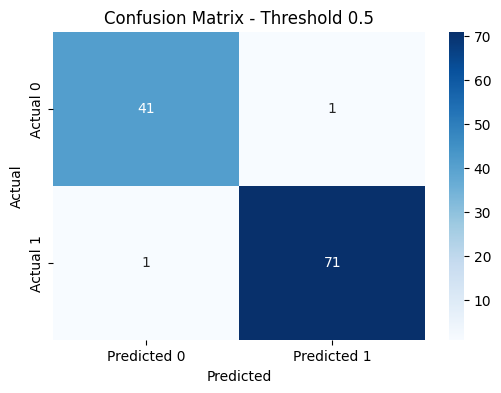

In [9]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_05,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix - Threshold 0.5")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1-score
0,0.3,0.972973,1.000000,0.986301
1,0.4,0.986111,0.986111,0.986111
2,0.5,0.986111,0.986111,0.986111
3,0.6,0.985507,0.944444,0.964539
4,0.7,0.985294,0.930556,0.957143


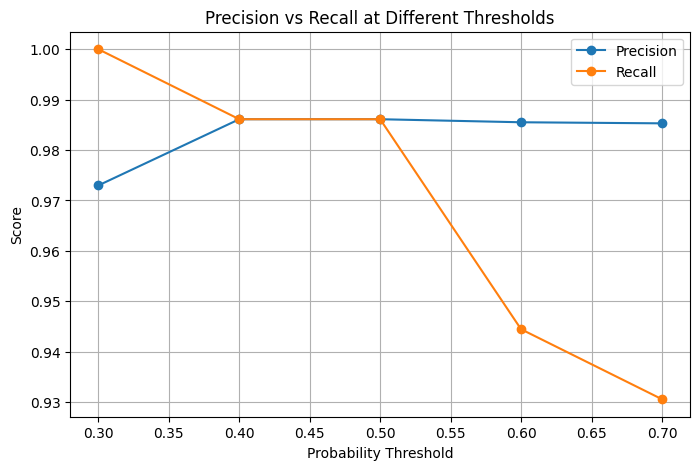

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
best_row = threshold_results.loc[
    threshold_results["F1-score"].idxmax()
]

print("Threshold with highest F1-score:")
print("Threshold:", best_row["Threshold"])
print("Precision:", round(best_row["Precision"], 4))
print("Recall:", round(best_row["Recall"], 4))
print("F1-score:", round(best_row["F1-score"], 4))

Threshold with highest F1-score:
Threshold: 0.3
Precision: 0.973
Recall: 1.0
F1-score: 0.9863


In [13]:
recommended_threshold = best_row["Threshold"]

print("Recommended threshold:", recommended_threshold)
print("\nReason:")
print(
    "This threshold provides the highest F1-score among the tested "
    "thresholds, giving a balance between precision and recall."
)

Recommended threshold: 0.3

Reason:
This threshold provides the highest F1-score among the tested thresholds, giving a balance between precision and recall.


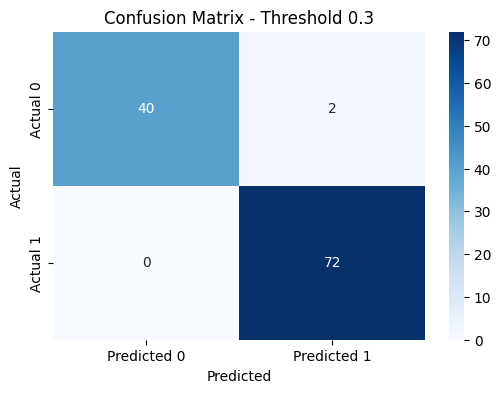

In [14]:
y_final = (y_proba >= recommended_threshold).astype(int)

final_cm = confusion_matrix(y_test, y_final)

plt.figure(figsize=(6, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title(f"Confusion Matrix - Threshold {recommended_threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model Interpretation

A confusion matrix was used to analyze the classification predictions and identify True Positives, True Negatives, False Positives, and False Negatives.

The default classification threshold of 0.5 was compared with several other thresholds.

Changing the threshold affects precision and recall. A lower threshold generally makes the model classify more observations as positive, which can increase recall but may also increase false positives.

A higher threshold generally makes the model more selective about positive predictions, which can improve precision but may reduce recall.

For this task, the threshold with the highest F1-score among the tested thresholds was selected as the recommended threshold because F1-score balances precision and recall.

The appropriate threshold ultimately depends on the practical cost of false positives and false negatives.